## Real vs Fake Trump Tweet Classification

**Deep Learning Project **

This notebook trains and compares four text classifiers on the task of telling **real** Donald Trump tweets apart from **fake** tweets generated by simple statistical models:

| # | Model | Why we use it |
|---|-------|---------------|
| 1 | TF-IDF + Logistic Regression | Baseline — the floor that all DL models must beat |
| 2 | Embedding + MLP | Smallest neural model, learns word embeddings |
| 3 | Bidirectional LSTM | Reads tweets sequentially, cares about word order |
| 4 | Transformer | Modern attention-based architecture, built ourselves |





### Quick environment check

In [ ]:
import os
import torch


In [ ]:
%%writefile data_loader.py
"""
data_loader.py
--------------
Shared data loading utility for the real-vs-fake tweet classifier project.

What it does:
- Loads real Trump tweets from tweets.csv (filtering out retweets / deletions)
- Loads fake tweets generated with the 3-gram Markov model
- Labels them: 1 = real, 0 = fake
- Returns a consistent train/test split with a fixed random seed so every
  classifier sees the exact same split, making comparisons fair
"""

import json
import pandas as pd
from sklearn.model_selection import train_test_split

REAL_PATH = "tweets.csv"
FAKE_PATH = "fake_tweets_3.json"

# Fixed random seed so every classifier gets the same split.
RANDOM_SEED = 42


def load_real_tweets(path: str = REAL_PATH) -> list[str]:
    """Load and clean real Trump tweets. Filter retweets + deleted"""
    df = pd.read_csv(path)
    df = df[df["isRetweet"] == "f"]
    df = df[df["isDeleted"] == "f"]
    # Drop near-empty tweets (just a URL or whitespace) 
    df = df[df["text"].str.strip().str.len() > 0]
    return df["text"].astype(str).tolist()


def load_fake_tweets(path: str = FAKE_PATH) -> list[str]:
    """3-gram fake tweets."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_data(test_size: float = 0.2, max_per_class: int | None = None):
    """
    Build the combined dataset with labels and split into train/test.

    Args:
        test_size: fraction held out for testing (default 20%)
        max_per_class: optional cap for quick experiments

    Returns:
        X_train, X_test, y_train, y_test
        Where X is a list[str] (tweet texts) and y is a list[int]
        (1 = real, 0 = fake).
    """
    real = load_real_tweets()
    fake = load_fake_tweets()

    if max_per_class is not None:
        real = real[:max_per_class]
        fake = fake[:max_per_class]

    print(f"Loaded {len(real):,} real tweets and {len(fake):,} fake tweets.")

    # Labels: 1 for real, 0 for fake.
    X = real + fake
    y = [1] * len(real) + [0] * len(fake)

    # Stratified split keeps the class balance equal in train and test.
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=RANDOM_SEED,
        stratify=y,
    )

    print(f"Train size: {len(X_train):,}   Test size: {len(X_test):,}")
    return X_train, X_test, y_train, y_test


if __name__ == "__main__":
    
    X_train, X_test, y_train, y_test = get_data()
    print("\nSample real tweet:", X_train[y_train.index(1)][:120])
    print("Sample fake tweet:", X_train[y_train.index(0)][:120])


In [ ]:
%%writefile tokenizer_util.py
"""
tokenizer_util.py
-----------------

- We want to SAVE the tokenizer alongside the model and reload it
  during evaluation, which keeps eval clean and reproducible

Special tokens (always at fixed indices):
    0 = <pad>   used to right-pad all sequences to the same length
    1 = <unk>   any word not in the vocabulary at training time
"""

import json
import re
from collections import Counter


PAD_IDX = 0
UNK_IDX = 1
SPECIAL_TOKENS = ["<pad>", "<unk>"]


def simple_tokenize(text: str) -> list[str]:
    """
    Very simple tokenization: lowercase, then split on non-word characters
    while keeping punctuation as separate tokens. Good enough for tweets.

    Examples:
        "Sleepy Joe is at it again!"
        -> ['sleepy', 'joe', 'is', 'at', 'it', 'again', '!']
    """
    text = text.lower()
    # Replace URLs with a placeholder token so the model can learn that
    # "tweets containing a URL" is itself a feature, without exploding vocab
    text = re.sub(r"https?://\S+", " <url> ", text)
    # Split on word characters; keep punctuation as separate tokens
    tokens = re.findall(r"[a-z0-9<>_]+|[^\w\s]", text)
    return tokens


class Tokenizer:
    """Word-level tokenizer with save/load."""

    def __init__(self, vocab_size: int = 20_000, min_freq: int = 2):
        self.vocab_size = vocab_size
        self.min_freq = min_freq
        self.word2idx: dict[str, int] = {}
        self.idx2word: list[str] = []

    def fit(self, texts: list[str]) -> None:
        """Build the vocabulary from a list of training texts."""
        counter: Counter = Counter()
        for t in texts:
            counter.update(simple_tokenize(t))

        # Reserve indices 0..len(SPECIAL_TOKENS)-1 for special tokens
        self.idx2word = list(SPECIAL_TOKENS)
        for word, freq in counter.most_common():
            if freq < self.min_freq:
                break
            if len(self.idx2word) >= self.vocab_size:
                break
            self.idx2word.append(word)

        self.word2idx = {w: i for i, w in enumerate(self.idx2word)}
        print(f"  Built vocabulary: {len(self.idx2word):,} tokens "
              f"(asked for max {self.vocab_size:,})")

    def encode(self, text: str, max_len: int) -> list[int]:
        """Encode a single text into a list of token IDs of length max_len.
        Pads with PAD_IDX (0) on the right; truncates if too long."""
        ids = [self.word2idx.get(w, UNK_IDX) for w in simple_tokenize(text)]
        ids = ids[:max_len]
        ids = ids + [PAD_IDX] * (max_len - len(ids))
        return ids

    def encode_batch(self, texts: list[str], max_len: int) -> list[list[int]]:
        return [self.encode(t, max_len) for t in texts]

    @property
    def vocab_len(self) -> int:
        return len(self.idx2word)

    def save(self, path: str) -> None:
        with open(path, "w", encoding="utf-8") as f:
            json.dump({
                "vocab_size": self.vocab_size,
                "min_freq": self.min_freq,
                "idx2word": self.idx2word,
            }, f, ensure_ascii=False)

    @classmethod
    def load(cls, path: str) -> "Tokenizer":
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        tok = cls(vocab_size=data["vocab_size"], min_freq=data["min_freq"])
        tok.idx2word = data["idx2word"]
        tok.word2idx = {w: i for i, w in enumerate(tok.idx2word)}
        return tok


if __name__ == "__main__":
    # Quick test
    t = Tokenizer(vocab_size=100, min_freq=1)
    t.fit(["Sleepy Joe is at it again!", "The economy is GREAT!"])
    enc = t.encode("Joe is great", max_len=10)
    print("Encoded:", enc)
    t.save("/tmp/tok_test.json")
    t2 = Tokenizer.load("/tmp/tok_test.json")
    print("Reloaded vocab size:", t2.vocab_len)


Overwriting tokenizer_util.py


## Classifier 1 — TF-IDF + Logistic Regression (Baseline)

A simple bag of words baseline. We count which words and word-pairs appear in each tweet (weighting rare but informative terms higher with TF-IDF), then train a linear classifier. Trains in seconds and gives us the **floor** that all deep learning models must beat.



Idea:
- A tweet is just a "bag of words"  we count which words appear.
- TF-IDF weights rare but informative words more than common ones
  ("Hillary" carries info, "the" doesn't).
- Logistic regression draws a linear boundary in that word-count space:
  "if these words appear, the tweet is more likely to be real (or fake)."
- We use both 1-grams AND 2-grams (single words and pairs) because a
  pair like "fake news" carries more signal than "fake" and "news"
  separately.

- It trains in seconds.
- It gives you the number that all the fancy DL models must beat.
- If logistic regression already gets 95%, your Markov fakes are easy
  to detect and DL probably isn't needed. That's a valid finding!


In [ ]:
"""
01_baseline_logreg.py
---------------------
CLASSIFIER #1 — TF-IDF + Logistic Regression (the baseline).

"""

import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

from data_loader import get_data


def main():
    # ------------------------------------------------------------------
    # 1. Load data
    # ------------------------------------------------------------------
    X_train, X_test, y_train, y_test = get_data()

    # ------------------------------------------------------------------
    # 2. Turn text into TF-IDF vectors
    # ------------------------------------------------------------------
    # max_features: keep only the 20,000 most informative tokens
    #               (otherwise the vocab is huge and slow)
    # ngram_range=(1, 2): use single words AND pairs of consecutive words
    # min_df=2: ignore words that appear in fewer than 2 tweets (noise)
    print("\nFitting TF-IDF vectorizer...")
    vectorizer = TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 2),
        min_df=2,
        lowercase=True,
    )
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)
    print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
    print(f"Train matrix shape: {X_train_vec.shape}")

    # ------------------------------------------------------------------
    # 3. Train Logistic Regression
    # ------------------------------------------------------------------
    # max_iter raised so it converges on 90k samples
    # C=1.0 is default regularization strength
    print("\nTraining logistic regression...")
    model = LogisticRegression(max_iter=1000, n_jobs=-1)
    model.fit(X_train_vec, y_train)

    # ------------------------------------------------------------------
    # 4. Evaluate
    # ------------------------------------------------------------------
    y_pred = model.predict(X_test_vec)

    print("\n=== Results ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, target_names=["fake", "real"]))
    print("Confusion matrix:")
    print("(rows = true label, columns = predicted)")
    print(confusion_matrix(y_test, y_pred))

    # ------------------------------------------------------------------
    # 5. Show the most predictive features (the fun part)
    # ------------------------------------------------------------------
    # Positive coefficients = pushes toward "real"
    # Negative coefficients = pushes toward "fake"
    feature_names = vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_real = sorted(zip(coefs, feature_names), reverse=True)[:15]
    top_fake = sorted(zip(coefs, feature_names))[:15]

    print("\n--- Top 15 features that PREDICT REAL tweets ---")
    for c, name in top_real:
        print(f"  {c:+.3f}   {name}")

    print("\n--- Top 15 features that PREDICT FAKE tweets ---")
    for c, name in top_fake:
        print(f"  {c:+.3f}   {name}")

    # ------------------------------------------------------------------
    # 6. Save model so other scripts 
    # ------------------------------------------------------------------
    joblib.dump((vectorizer, model), "model_01_logreg.joblib")
    print("\nSaved model to: model_01_logreg.joblib")


if __name__ == "__main__":
    main()


Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting TF-IDF vectorizer...
Vocabulary size: 20,000
Train matrix shape: (73196, 20000)

Training logistic regression...

=== Results ===
Accuracy: 0.5907

Classification report:
              precision    recall  f1-score   support

        fake       0.58      0.65      0.61      9091
        real       0.61      0.53      0.57      9208

    accuracy                           0.59     18299
   macro avg       0.59      0.59      0.59     18299
weighted avg       0.59      0.59      0.59     18299

Confusion matrix:
(rows = true label, columns = predicted)
[[5895 3196]
 [4294 4914]]

--- Top 15 features that PREDICT REAL tweets ---
  +24.304   amp
  +15.305   http co
  +11.615   http
  +7.118   mr trump
  +4.654   like champion
  +4.281   jobs jobs
  +4.093   co
  +3.510   have clue
  +3.389   military vets
  +3.338   tickets https
  +3.338   together we
  +3.057   like billionaire
  +2.986   at

## Classifier 2 — Embedding + MLP

Each word gets converted into a learned 64-dimensional vector (an "embedding"), all the vectors in a tweet are averaged, and the result is fed through a small feed-forward network. This is the simplest neural approach but still bag-of-words in spirit (word order is ignored), but with learned representations instead of hand-crafted TF-IDF counts.




- Tweets are short (<= 60 tokens), so a heavyweight sequence model is overkill
- A learned embedding lets the model discover useful word-level features
  that the bag-of-words baseline (#1) can't (e.g., that "BIGLY" patterns
  with "Tremendous" but is rare with "Hillary")
- Average pooling is a deliberate weakness: it ignores word order. We use
  it here to provide a clean stepping stone from to LSTM.

REGULARIZATION CHOICES:
- Dropout (p=0.3) between layers to reduce overfitting
- Weight decay = 1e-5 on the optimizer (mild L2)
- Early stopping on validation loss

OPTIMIZER: Adam, lr=1e-3. Standard for small NLP models, robust default.
LOSS:      BCEWithLogitsLoss (binary, more numerically stable than
           sigmoid + BCELoss).

Device: cuda
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting tokenizer...
  Built vocabulary: 20,000 tokens (asked for max 20,000)

Model:
EmbeddingMLP(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (relu): ReLU()
)
Total parameters: 1,284,225

Training...
  Epoch  1/8  loss=0.6484 acc=0.6079  val_loss=0.6114 val_acc=0.6784
  Epoch  2/8  loss=0.5786 acc=0.7014  val_loss=0.5490 val_acc=0.7293
  Epoch  3/8  loss=0.5233 acc=0.7427  val_loss=0.5103 val_acc=0.7576
  Epoch  4/8  loss=0.4802 acc=0.7719  val_loss=0.4905 val_acc=0.7651
  Epoch  5/8  loss=0.4495 acc=0.7912  val_loss=0.4763 val_acc=0.7788
  Epoch  6/8  loss=0.4241 acc=0.8074  val_loss=0.4763 val_acc=0.7818
  Epoch  7/8  loss=0.4017 acc=0.8222  val_loss=0.4642 val_acc=0.7788
  Epoch  8/8  loss=0.3837 acc=0.8312  val

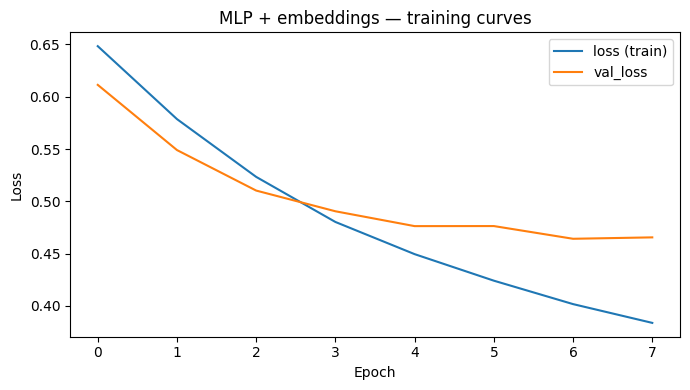

In [14]:
"""
02_mlp_embedding.py
-------------------------------------
CLASSIFIER #2 — Word embeddings + average pool + small MLP.

"""

import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

from data_loader import get_data
from tokenizer_util import Tokenizer, PAD_IDX


# ------------------------- Hyperparameters -------------------------
VOCAB_SIZE = 20_000
MAX_LEN = 60
EMBED_DIM = 64
HIDDEN_DIM = 64
DROPOUT = 0.3
BATCH_SIZE = 128
EPOCHS = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 2     # early stopping: stop if val loss doesn't improve N epochs
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------- Dataset -------------------------
class TweetDataset(Dataset):
    """Holds (token_ids, label) tensors."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.ids = torch.tensor(
            tokenizer.encode_batch(texts, max_len), dtype=torch.long
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.ids[i], self.labels[i]


# ------------------------- Model -------------------------
class EmbeddingMLP(nn.Module):
    """
    Architecture:
        token_ids -> embedding -> masked mean pool -> Linear -> ReLU
                                                   -> Dropout -> Linear -> logit
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout):
        super().__init__()
        # padding_idx=PAD_IDX so that pad tokens have a zero embedding
        # and don't contribute gradient
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x: (batch, max_len) of token IDs
        emb = self.embedding(x)            # (batch, max_len, embed_dim)
        # Mean over non-padded positions:
        mask = (x != PAD_IDX).unsqueeze(-1).float()        # (batch, max_len, 1)
        summed = (emb * mask).sum(dim=1)                   # (batch, embed_dim)
        counts = mask.sum(dim=1).clamp(min=1.0)            # avoid /0
        pooled = summed / counts                           # (batch, embed_dim)

        h = self.relu(self.fc1(pooled))
        h = self.dropout(h)
        logit = self.fc2(h).squeeze(-1)    # (batch,)
        return logit


# ------------------------- Train / eval helpers -------------------------
def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, n, n_correct = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ids, labels in loader:
            ids, labels = ids.to(DEVICE), labels.to(DEVICE)
            logits = model(ids)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            n_correct += (preds == labels).sum().item()
            n += labels.size(0)
            total_loss += loss.item() * labels.size(0)
    return total_loss / n, n_correct / n


def main():
    torch.manual_seed(SEED)
    print(f"Device: {DEVICE}")

    # 1) Data
    X_train, X_test, y_train, y_test = get_data()

    # Split off a validation set from training (10%)
    n_val = int(0.1 * len(X_train))
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    X_train, y_train = X_train[:-n_val], y_train[:-n_val]

    # 2) Tokenizer — fit on TRAINING data only (don't leak val/test)
    print("\nFitting tokenizer...")
    tokenizer = Tokenizer(vocab_size=VOCAB_SIZE, min_freq=2)
    tokenizer.fit(X_train)

    # 3) Datasets + loaders
    train_ds = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    # 4) Model, loss, optimizer
    model = EmbeddingMLP(
        vocab_size=tokenizer.vocab_len,
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)
    print("\nModel:")
    print(model)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {n_params:,}")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )

    # 5) Training loop with early stopping
    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_state = None

    print("\nTraining...")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, criterion, False)
        history["loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"  Epoch {epoch:2d}/{EPOCHS}  "
              f"loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    # 6) Final evaluation on test set
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, labels in test_loader:
            ids = ids.to(DEVICE)
            logits = model(ids)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))

    print("\n=== Test results ===")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(classification_report(all_labels, all_preds, target_names=["fake", "real"]))
    print(confusion_matrix(all_labels, all_preds))

    # 7) Save model, tokenizer, history
    torch.save({
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_len,
            "embed_dim": EMBED_DIM,
            "hidden_dim": HIDDEN_DIM,
            "dropout": DROPOUT,
            "max_len": MAX_LEN,
        },
    }, "model_02_mlp.pt")
    tokenizer.save("tokenizer_02.json")
    with open("history_02_mlp.json", "w") as f:
        json.dump(history, f)
    print("\nSaved: model_02_mlp.pt, tokenizer_02.json, history_02_mlp.json")

    # 8) Loss curve plot (style of the slide's val_loss diagram)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["loss"], label="loss (train)")
    ax.plot(history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("MLP + embeddings — training curves")
    ax.legend()
    plt.tight_layout()
    plt.savefig("curves_02_mlp.png", dpi=150)
    print("Saved: curves_02_mlp.png")


if __name__ == "__main__":
    main()


## Classifier 3 — Bidirectional LSTM

LIMITATIONS WE EXPECT:
- The 3-gram Markov fakes already disrupt order locally (~3-token windows).
  An LSTM might struggle to catch this because the local order looks fine;
  it's the long-range coherence that breaks.

REGULARIZATION:
- Dropout in the LSTM (between stacked layers if num_layers>1)
- Dropout on the classifier head
- Weight decay on the optimizer
- Early stopping on val loss

OPTIMIZER: Adam, lr=1e-3, weight_decay=1e-5.
LOSS:      BCEWithLogitsLoss.

DEPENDENCIES: pip install torch scikit-learn pandas matplotlib

Unlike the MLP, **word order matters** here.



Device: cuda
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting tokenizer...
  Built vocabulary: 20,000 tokens (asked for max 20,000)

Model:
BiLSTMClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)
Total parameters: 1,346,689

Training...
  Epoch  1/8  loss=0.5278 acc=0.7127  val_loss=0.3905 val_acc=0.8220
  Epoch  2/8  loss=0.3521 acc=0.8399  val_loss=0.3411 val_acc=0.8441
  Epoch  3/8  loss=0.3070 acc=0.8641  val_loss=0.3342 val_acc=0.8496
  Epoch  4/8  loss=0.2698 acc=0.8842  val_loss=0.3044 val_acc=0.8645
  Epoch  5/8  loss=0.2326 acc=0.9027  val_loss=0.2978 val_acc=0.8757
  Epoch  6/8  loss=0.2002 acc=0.9193  val_loss=0.2945 val_acc=0.8755
  Epoch  7/8  loss=0.1675 acc=0.9342  val_loss=0.3075 val_acc=0.8781
  Epoch  8/8  loss=0.1387 acc=0.9464  val_los

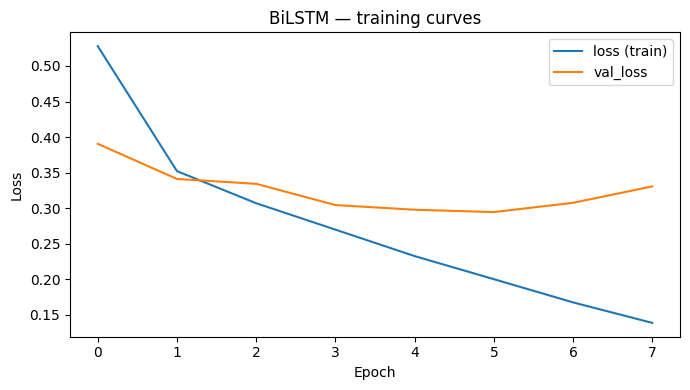

In [15]:
"""
03_rnn_lstm.py
--------------------------------
CLASSIFIER #3 — Bidirectional LSTM encoder + classifier head.

- An LSTM reads the tweet ONE WORD AT A TIME, maintaining a hidden state
  that captures the sequence so far. This is: h_t = f(x_t, h_{t-1})

- Bidirectional: we read left->right AND right->left, then concatenate
  both summaries. This helps because some style markers depend on context
  from both sides (e.g., capitalization patterns in mid tweet).

- We use the LAST hidden state from each direction (concatenated) as
  our "tweet summary," then pass it through a small classifier head.

"""
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

from data_loader import get_data
from tokenizer_util import Tokenizer, PAD_IDX


VOCAB_SIZE = 20_000
MAX_LEN = 60
EMBED_DIM = 64
LSTM_HIDDEN = 64
LSTM_LAYERS = 1
DROPOUT = 0.3
BATCH_SIZE = 128
EPOCHS = 8
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 2
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------- Dataset -------------------------
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        encoded = tokenizer.encode_batch(texts, max_len)
        self.ids = torch.tensor(encoded, dtype=torch.long)
        # Length of each sequence BEFORE padding (needed for pack_padded)
        self.lengths = torch.tensor(
            [max(1, sum(1 for t in row if t != PAD_IDX)) for row in encoded],
            dtype=torch.long,
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.ids[i], self.lengths[i], self.labels[i]


# ------------------------- Model -------------------------
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden, num_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        # 2 * hidden because bidirectional concatenates forward + backward
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(2 * hidden, 1)

    def forward(self, ids, lengths):
        emb = self.embedding(ids)                          # (B, L, E)

        # pack_padded so the LSTM ignores pad tokens entirely
        # (Significantly improves quality and speed)
        packed = pack_padded_sequence(
            emb, lengths.cpu(),
            batch_first=True, enforce_sorted=False,
        )
        _, (h_n, _) = self.lstm(packed)
        # h_n shape: (num_layers * 2, B, hidden)
        # Concatenate the final forward + backward hidden states of the
        # top layer:
        h_fwd = h_n[-2]    # (B, hidden)
        h_bwd = h_n[-1]    # (B, hidden)
        h = torch.cat([h_fwd, h_bwd], dim=-1)              # (B, 2*hidden)
        h = self.dropout(h)
        return self.classifier(h).squeeze(-1)              # (B,)


# ------------------------- Helpers -------------------------
def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, n, n_correct = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ids, lengths, labels in loader:
            ids, lengths, labels = (ids.to(DEVICE),
                                    lengths.to(DEVICE),
                                    labels.to(DEVICE))
            logits = model(ids, lengths)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping prevents exploding gradients
                # (a real risk in RNNs with long sequences)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            n_correct += (preds == labels).sum().item()
            n += labels.size(0)
            total_loss += loss.item() * labels.size(0)
    return total_loss / n, n_correct / n


def main():
    torch.manual_seed(SEED)
    print(f"Device: {DEVICE}")

    X_train, X_test, y_train, y_test = get_data()
    n_val = int(0.1 * len(X_train))
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    X_train, y_train = X_train[:-n_val], y_train[:-n_val]

    print("\nFitting tokenizer...")
    tokenizer = Tokenizer(vocab_size=VOCAB_SIZE, min_freq=2)
    tokenizer.fit(X_train)

    train_ds = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    model = BiLSTMClassifier(
        vocab_size=tokenizer.vocab_len,
        embed_dim=EMBED_DIM,
        hidden=LSTM_HIDDEN,
        num_layers=LSTM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)
    print("\nModel:")
    print(model)
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )

    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best_val_loss, epochs_no_improve = float("inf"), 0
    best_state = None

    print("\nTraining...")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, criterion, False)
        history["loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"  Epoch {epoch:2d}/{EPOCHS}  "
              f"loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, lengths, labels in test_loader:
            ids, lengths = ids.to(DEVICE), lengths.to(DEVICE)
            logits = model(ids, lengths)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))

    print("\n=== Test results ===")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(classification_report(all_labels, all_preds, target_names=["fake", "real"]))
    print(confusion_matrix(all_labels, all_preds))

    torch.save({
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_len,
            "embed_dim": EMBED_DIM,
            "hidden": LSTM_HIDDEN,
            "num_layers": LSTM_LAYERS,
            "dropout": DROPOUT,
            "max_len": MAX_LEN,
        },
    }, "model_03_lstm.pt")
    tokenizer.save("tokenizer_03.json")
    with open("history_03_lstm.json", "w") as f:
        json.dump(history, f)
    print("\nSaved: model_03_lstm.pt, tokenizer_03.json, history_03_lstm.json")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["loss"], label="loss (train)")
    ax.plot(history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("BiLSTM — training curves")
    ax.legend()
    plt.tight_layout()
    plt.savefig("curves_03_lstm.png", dpi=150)
    print("Saved: curves_03_lstm.png")


if __name__ == "__main__":
    main()


## Classifier 4 — Transformer Encoder (from scratch)

A 2-block Transformer encoder with multi-head self-attention, built using `nn.TransformerEncoderLayer` plus a hand-written sinusoidal positional encoding. Each position can attend to every other position in the tweet, then we mean-pool across positions and feed the result to a classifier head.

**Caveat:** Transformers are data hungry. With ~90k labeled tweets we expect some overfitting (val_loss going up while train_loss goes down) — we use small embedding dim, only 2 blocks, and heavy dropout to keep this under control.




Device: cuda
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299

Fitting tokenizer...
  Built vocabulary: 20,000 tokens (asked for max 20,000)

Model:
TransformerClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (pos_enc): SinusoidalPositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  Epoch  1/8  loss=0.4822 acc=0.7447  val_loss=0.4038 val_acc=0.8020
  Epoch  2/8  loss=0.3875 acc=0.8086  val_loss=0.3694 val_acc=0.8248
  Epoch  3/8  loss=0.3532 acc=0.8339  val_loss=0.3384 val_acc=0.8421
  Epoch  4/8  loss=0.3290 acc=0.8492  val_loss=0.3371 val_acc=0.8403
  Epoch  5/8  loss=0.3119 acc=0.8583  val_loss=0.3146 val_acc=0.8579
  Epoch  6/8  loss=0.2915 acc=0.8697  val_loss=0.3027 val_acc=0.8645
  Epoch  7/8  loss=0.2775 acc=0.8769  val_loss=0.2897 val_acc=0.8690
  Epoch  8/8  loss=0.2626 acc=0.8858  val_loss=0.2952 val_acc=0.8699

=== Test results ===
Accuracy: 0.8653
              precision    recall  f1-score   support

        fake       0.86      0.87      0.87      9091
        real       0.87      0.86      0.87      9208

    accuracy                           0.87     18299
   macro avg       0.87      0.87      0.87     18299
weighted avg       0.87      0.87      0.87     18299

[[7903 1188]
 [1277 7931]]

Saved: model_04_transformer.pt, tokenizer_04.json, his

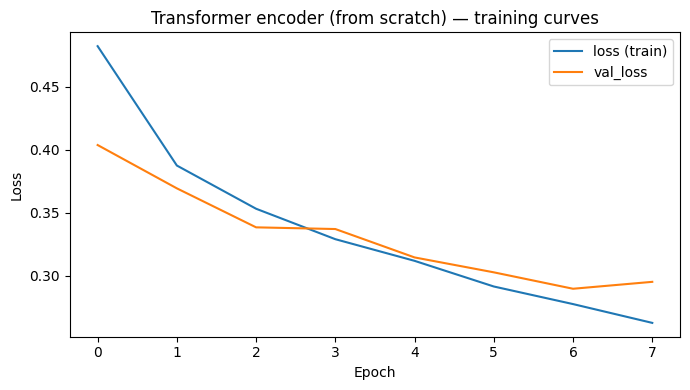

In [16]:
"""
04_transformer_scratch.py
-------------------------------------------
CLASSIFIER #4 — Transformer encoder + classifier head, built in PyTorch.

Input embedding
        + Positional encoding              (slide: "Positional Encoding")
    -> N stacked encoder blocks, each:
        - Multi-head self-attention        (Q, K, V matrices, h heads)
        - Add & Norm (residual + LayerNorm)
        - Position-wise FFN                (the "Feed Forward" box)
        - Add & Norm
    -> Mean pool across positions
    -> Small classifier head -> logit

We use nn.TransformerEncoderLayer for the encoder block (which contains
the multi-head attention, FFN, and LayerNorms already), and write the
positional encoding ourselves so the sin/cos pattern from your slide is
visible in code.

WHY we choose it for our task:
- Tweets are short, so self-attention's O(L^2) cost is cheap
- Multi-head attention lets the model learn different "feature detectors"
  in parallel, exactly the diversity argument from your "Why Multi-Head
  Attention?" slide
- We use the ENCODER only because we are doing CLASSIFICATION, not
  generation.

CAVEAT:
- Transformers are very data-hungry. ~90k labeled tweets is small for
  training a Transformer from scratch. we expect VAL_LOSS to start going
  up while TRAIN_LOSS goes down (the exact overfitting curve shown in
  your "Text Classification with Transformer" slide). That's WHY
  pretrained models (#5) exist. Our hyperparameters (small embed dim,
  2 blocks, heavy dropout) are deliberately tuned to limit overfitting.

REGULARIZATION:
- Dropout = 0.2 inside each transformer block + on classifier head
- Weight decay = 1e-5
- Early stopping on val loss

OPTIMIZER: Adam, lr=5e-4 (lower than #2/#3 because transformers are
           sensitive to learning rate)
LOSS:      BCEWithLogitsLoss

"""

import json
import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt

from data_loader import get_data
from tokenizer_util import Tokenizer, PAD_IDX


# ------------------------- Hyperparameters -------------------------
VOCAB_SIZE = 20_000
MAX_LEN = 60
EMBED_DIM = 64        # d_model
NUM_HEADS = 4         # h ; d_k = d_model / h = 16
FF_DIM = 128          # hidden width of the position-wise FFN
NUM_BLOCKS = 2        # how many encoder blocks to stack ("Nx" in slides)
DROPOUT = 0.2
BATCH_SIZE = 128
EPOCHS = 8
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 1e-5
PATIENCE = 2
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------- Dataset -------------------------
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.ids = torch.tensor(
            tokenizer.encode_batch(texts, max_len), dtype=torch.long
        )
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        return self.ids[i], self.labels[i]


# ------------------------- Positional encoding -------------------------
class SinusoidalPositionalEncoding(nn.Module):
    """
    Implements the sin/cos positional encoding from Vaswani et al. 2017,
    matching the heatmap in your "Positional Encoding" slide.

    For each position pos and dimension i:
        PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
        PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """
    def __init__(self, max_len, d_model):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float)
            * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        # register_buffer = persistent but not a learnable parameter
        self.register_buffer("pe", pe.unsqueeze(0))    # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, L, d_model)
        return x + self.pe[:, : x.size(1), :]


# ------------------------- Model -------------------------
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 num_blocks, max_len, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=PAD_IDX)
        self.pos_enc = SinusoidalPositionalEncoding(max_len, embed_dim)

        # PyTorch's TransformerEncoderLayer implements exactly:
        #   x -> MultiHeadAttention -> +residual -> LayerNorm
        #     -> FFN(ReLU)            -> +residual -> LayerNorm
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,    # so input is (batch, seq, feat) not (seq, batch, feat)
            activation="relu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_blocks)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1),
        )

    def forward(self, ids):
        # 1) Token embeddings + positional encoding (X + P from the slide)
        x = self.embedding(ids)                    # (B, L, D)
        x = self.pos_enc(x)

        # 2) Build the padding mask: True where token is PAD
        #    The encoder will ignore those positions during attention.
        pad_mask = (ids == PAD_IDX)                # (B, L)

        # 3) Stack of transformer encoder blocks
        x = self.encoder(x, src_key_padding_mask=pad_mask)   # (B, L, D)

        # 4) Pool across positions, ignoring padding (mean over non-pad)
        mask = (~pad_mask).unsqueeze(-1).float()             # (B, L, 1)
        summed = (x * mask).sum(dim=1)                       # (B, D)
        counts = mask.sum(dim=1).clamp(min=1.0)              # (B, 1)
        pooled = summed / counts                             # (B, D)

        # 5) Classifier head
        logit = self.classifier(self.dropout(pooled)).squeeze(-1)
        return logit


# ------------------------- Helpers -------------------------
def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, n, n_correct = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ids, labels in loader:
            ids, labels = ids.to(DEVICE), labels.to(DEVICE)
            logits = model(ids)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).float()
            n_correct += (preds == labels).sum().item()
            n += labels.size(0)
            total_loss += loss.item() * labels.size(0)
    return total_loss / n, n_correct / n


def main():
    torch.manual_seed(SEED)
    print(f"Device: {DEVICE}")

    X_train, X_test, y_train, y_test = get_data()
    n_val = int(0.1 * len(X_train))
    X_val, y_val = X_train[-n_val:], y_train[-n_val:]
    X_train, y_train = X_train[:-n_val], y_train[:-n_val]

    print("\nFitting tokenizer...")
    tokenizer = Tokenizer(vocab_size=VOCAB_SIZE, min_freq=2)
    tokenizer.fit(X_train)

    train_ds = TweetDataset(X_train, y_train, tokenizer, MAX_LEN)
    val_ds   = TweetDataset(X_val,   y_val,   tokenizer, MAX_LEN)
    test_ds  = TweetDataset(X_test,  y_test,  tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    model = TransformerClassifier(
        vocab_size=tokenizer.vocab_len,
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        num_blocks=NUM_BLOCKS,
        max_len=MAX_LEN,
        dropout=DROPOUT,
    ).to(DEVICE)
    print("\nModel:")
    print(model)
    print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
    )

    history = {"loss": [], "val_loss": [], "acc": [], "val_acc": []}
    best_val_loss, epochs_no_improve = float("inf"), 0
    best_state = None

    print("\nTraining Transformer encoder from scratch...")
    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, criterion, True)
        va_loss, va_acc = run_epoch(model, val_loader,   optimizer, criterion, False)
        history["loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["acc"].append(tr_acc)
        history["val_acc"].append(va_acc)
        print(f"  Epoch {epoch:2d}/{EPOCHS}  "
              f"loss={tr_loss:.4f} acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

        if va_loss < best_val_loss - 1e-4:
            best_val_loss = va_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= PATIENCE:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for ids, labels in test_loader:
            ids = ids.to(DEVICE)
            logits = model(ids)
            preds = (torch.sigmoid(logits) >= 0.5).long().cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy().astype(int))

    print("\n=== Test results ===")
    print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
    print(classification_report(all_labels, all_preds, target_names=["fake", "real"]))
    print(confusion_matrix(all_labels, all_preds))

    torch.save({
        "model_state_dict": model.state_dict(),
        "config": {
            "vocab_size": tokenizer.vocab_len,
            "embed_dim": EMBED_DIM,
            "num_heads": NUM_HEADS,
            "ff_dim": FF_DIM,
            "num_blocks": NUM_BLOCKS,
            "max_len": MAX_LEN,
            "dropout": DROPOUT,
        },
    }, "model_04_transformer.pt")
    tokenizer.save("tokenizer_04.json")
    with open("history_04_transformer.json", "w") as f:
        json.dump(history, f)
    print("\nSaved: model_04_transformer.pt, tokenizer_04.json, history_04_transformer.json")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(history["loss"], label="loss (train)")
    ax.plot(history["val_loss"], label="val_loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title("Transformer encoder (from scratch) — training curves")
    ax.legend()
    plt.tight_layout()
    plt.savefig("curves_04_transformer.png", dpi=150)
    print("Saved: curves_04_transformer.png")


if __name__ == "__main__":
    main()


## Comparison — all classifiers side by side

Loading each trained model & re-evaluates it on the same held out test set, prints a summary table (accuracy + F1), and saves two plots:
- `comparison_accuracy.png`  bar chart of test accuracy
- `training_curves.png` loss curves for each neural model

DistilBERT will appear as "(not trained)"


Device: cuda

Evaluating LogReg...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating MLP...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating BiLSTM...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating Transformer (scratch)...
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Evaluating DistilBERT...

=== Model comparison ===
Model                          Accuracy         F1
--------------------------------------------------
LogReg (TF-IDF)                  0.5907     0.5675
Embedding+MLP                    0.7792     0.7863
BiLSTM                           0.8789     0.8797
Transformer (scratch)            0.8653     0.8655
DistilBERT (fine-tuned)               (not trained)

Saved: comparison_accuracy.png
Saved: training_curves.png


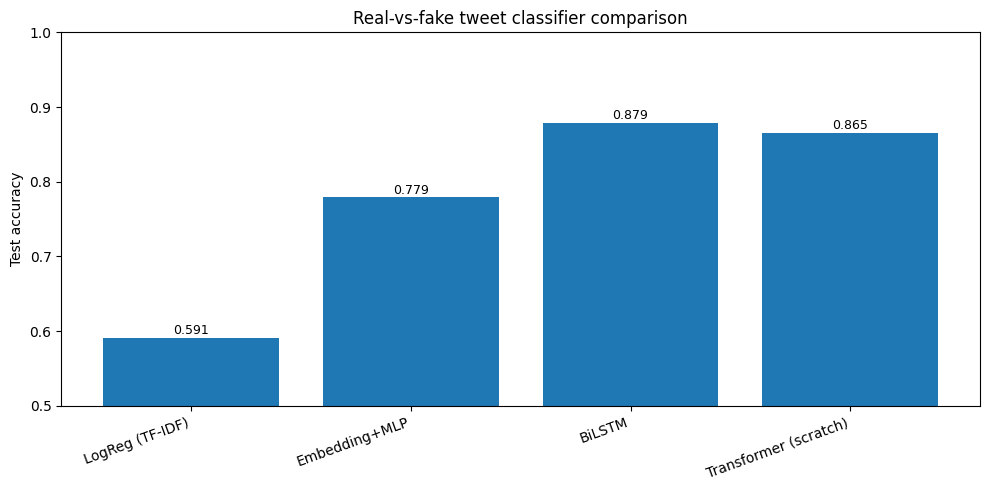

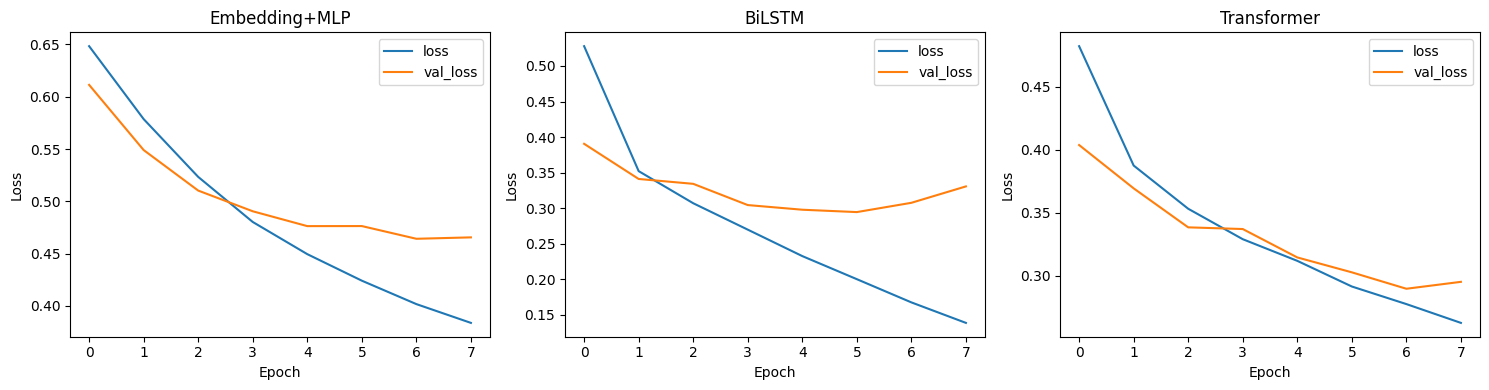

In [17]:
"""
06_compare_results.py
---------------------------------------
prints a table and saves two plots:
   - comparison_accuracy.png   bar chart of test accuracy
   - training_curves.png       loss/val_loss curves for each NN model

"""

import json
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

from data_loader import get_data
from tokenizer_util import Tokenizer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ---------------------------------------------------------------------------
# Per-model evaluators
# ---------------------------------------------------------------------------
def evaluate_logreg():
    import joblib
    if not os.path.exists("model_01_logreg.joblib"):
        return None
    vectorizer, model = joblib.load("model_01_logreg.joblib")
    _, X_test, _, y_test = get_data()
    y_pred = model.predict(vectorizer.transform(X_test))
    return accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)


def _evaluate_pytorch(model_path, tok_path, model_builder, needs_lengths=False):
    """Generic loader for our PyTorch classifiers."""
    if not os.path.exists(model_path) or not os.path.exists(tok_path):
        return None
    from tokenizer_util import PAD_IDX

    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    tokenizer = Tokenizer.load(tok_path)
    model = model_builder(ckpt["config"], tokenizer.vocab_len).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    _, X_test, _, y_test = get_data()
    max_len = ckpt["config"]["max_len"]
    ids = torch.tensor(tokenizer.encode_batch(X_test, max_len), dtype=torch.long)

    preds = []
    with torch.no_grad():
        for i in range(0, len(ids), 256):
            batch = ids[i:i+256].to(DEVICE)
            if needs_lengths:
                lengths = torch.tensor(
                    [max(1, (row != PAD_IDX).sum().item()) for row in batch],
                    dtype=torch.long,
                ).to(DEVICE)
                logits = model(batch, lengths)
            else:
                logits = model(batch)
            preds.extend((torch.sigmoid(logits) >= 0.5).long().cpu().numpy())

    return accuracy_score(y_test, preds), f1_score(y_test, preds)


def evaluate_mlp():
    return _evaluate_pytorch(
        "model_02_mlp.pt", "tokenizer_02.json",
        model_builder=lambda cfg, vs: _build_mlp(cfg, vs),
    )


def _build_mlp(cfg, vocab_size):
    """Rebuild the MLP architecture from 02_mlp_embedding.py."""
    import torch.nn as nn
    from tokenizer_util import PAD_IDX

    class EmbeddingMLP(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.fc1 = nn.Linear(cfg["embed_dim"], cfg["hidden_dim"])
            self.fc2 = nn.Linear(cfg["hidden_dim"], 1)
            self.dropout = nn.Dropout(cfg["dropout"])
            self.relu = nn.ReLU()

        def forward(self, x):
            emb = self.embedding(x)
            mask = (x != PAD_IDX).unsqueeze(-1).float()
            summed = (emb * mask).sum(dim=1)
            counts = mask.sum(dim=1).clamp(min=1.0)
            pooled = summed / counts
            h = self.relu(self.fc1(pooled))
            h = self.dropout(h)
            return self.fc2(h).squeeze(-1)
    return EmbeddingMLP()


def evaluate_lstm():
    return _evaluate_pytorch(
        "model_03_lstm.pt", "tokenizer_03.json",
        model_builder=lambda cfg, vs: _build_lstm(cfg, vs),
        needs_lengths=True,
    )


def _build_lstm(cfg, vocab_size):
    import torch.nn as nn
    from torch.nn.utils.rnn import pack_padded_sequence
    from tokenizer_util import PAD_IDX

    class BiLSTMClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.lstm = nn.LSTM(
                input_size=cfg["embed_dim"], hidden_size=cfg["hidden"],
                num_layers=cfg["num_layers"], bidirectional=True,
                batch_first=True,
                dropout=cfg["dropout"] if cfg["num_layers"] > 1 else 0.0,
            )
            self.dropout = nn.Dropout(cfg["dropout"])
            self.classifier = nn.Linear(2 * cfg["hidden"], 1)

        def forward(self, ids, lengths):
            emb = self.embedding(ids)
            packed = pack_padded_sequence(
                emb, lengths.cpu(),
                batch_first=True, enforce_sorted=False,
            )
            _, (h_n, _) = self.lstm(packed)
            h = torch.cat([h_n[-2], h_n[-1]], dim=-1)
            return self.classifier(self.dropout(h)).squeeze(-1)
    return BiLSTMClassifier()


def evaluate_transformer():
    return _evaluate_pytorch(
        "model_04_transformer.pt", "tokenizer_04.json",
        model_builder=lambda cfg, vs: _build_transformer(cfg, vs),
    )


def _build_transformer(cfg, vocab_size):
    import math
    import torch.nn as nn
    from tokenizer_util import PAD_IDX

    class SinusoidalPositionalEncoding(nn.Module):
        def __init__(self, max_len, d_model):
            super().__init__()
            pe = torch.zeros(max_len, d_model)
            pos = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float)
                            * -(math.log(10000.0) / d_model))
            pe[:, 0::2] = torch.sin(pos * div)
            pe[:, 1::2] = torch.cos(pos * div)
            self.register_buffer("pe", pe.unsqueeze(0))

        def forward(self, x):
            return x + self.pe[:, : x.size(1), :]

    class TransformerClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.embedding = nn.Embedding(vocab_size, cfg["embed_dim"],
                                          padding_idx=PAD_IDX)
            self.pos_enc = SinusoidalPositionalEncoding(
                cfg["max_len"], cfg["embed_dim"])
            layer = nn.TransformerEncoderLayer(
                d_model=cfg["embed_dim"], nhead=cfg["num_heads"],
                dim_feedforward=cfg["ff_dim"], dropout=cfg["dropout"],
                batch_first=True, activation="relu",
            )
            self.encoder = nn.TransformerEncoder(layer, num_layers=cfg["num_blocks"])
            self.dropout = nn.Dropout(cfg["dropout"])
            self.classifier = nn.Sequential(
                nn.Linear(cfg["embed_dim"], cfg["embed_dim"]),
                nn.ReLU(),
                nn.Dropout(cfg["dropout"]),
                nn.Linear(cfg["embed_dim"], 1),
            )

        def forward(self, ids):
            x = self.embedding(ids)
            x = self.pos_enc(x)
            pad_mask = (ids == PAD_IDX)
            x = self.encoder(x, src_key_padding_mask=pad_mask)
            mask = (~pad_mask).unsqueeze(-1).float()
            pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
            return self.classifier(self.dropout(pooled)).squeeze(-1)
    return TransformerClassifier()


def evaluate_distilbert():
    path = "model_05_distilbert"
    if not os.path.isdir(path):
        return None
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSequenceClassification.from_pretrained(path).to(DEVICE)
    model.eval()

    _, X_test, _, y_test = get_data()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_test), 64):
            batch = X_test[i:i+64]
            enc = tok(batch, truncation=True, padding=True,
                      max_length=64, return_tensors="pt").to(DEVICE)
            out = model(**enc).logits.argmax(dim=-1).cpu().numpy()
            preds.extend(out)
    return accuracy_score(y_test, preds), f1_score(y_test, preds)


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    print(f"Device: {DEVICE}\n")
    results = {}

    print("Evaluating LogReg...");           results["LogReg (TF-IDF)"]         = evaluate_logreg()
    print("Evaluating MLP...");              results["Embedding+MLP"]           = evaluate_mlp()
    print("Evaluating BiLSTM...");           results["BiLSTM"]                  = evaluate_lstm()
    print("Evaluating Transformer (scratch)..."); results["Transformer (scratch)"] = evaluate_transformer()
    print("Evaluating DistilBERT...");       results["DistilBERT (fine-tuned)"] = evaluate_distilbert()

    # Print summary
    print("\n=== Model comparison ===")
    print(f"{'Model':<28s} {'Accuracy':>10s} {'F1':>10s}")
    print("-" * 50)
    for name, r in results.items():
        if r is None:
            print(f"{name:<28s} {'(not trained)':>22s}")
        else:
            acc, f1 = r
            print(f"{name:<28s} {acc:>10.4f} {f1:>10.4f}")

    # Bar chart
    trained = {k: v for k, v in results.items() if v is not None}
    if trained:
        names = list(trained.keys())
        accs = [v[0] for v in trained.values()]
        plt.figure(figsize=(10, 5))
        bars = plt.bar(names, accs)
        plt.ylim(0.5, 1.0)
        plt.ylabel("Test accuracy")
        plt.title("Real-vs-fake tweet classifier comparison")
        for bar, acc in zip(bars, accs):
            plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.005,
                     f"{acc:.3f}", ha="center", fontsize=9)
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.savefig("comparison_accuracy.png", dpi=150)
        print("\nSaved: comparison_accuracy.png")

    # Training curves
    histories = [
        ("Embedding+MLP", "history_02_mlp.json"),
        ("BiLSTM",        "history_03_lstm.json"),
        ("Transformer",   "history_04_transformer.json"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (label, path) in zip(axes, histories):
        if not os.path.exists(path):
            ax.set_title(f"{label}\n(not trained)"); ax.axis("off"); continue
        with open(path) as f:
            h = json.load(f)
        ax.plot(h["loss"], label="loss")
        ax.plot(h["val_loss"], label="val_loss")
        ax.set_title(label); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend()
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    print("Saved: training_curves.png")


if __name__ == "__main__":
    main()


## Download all results



In [ ]:
import os
import zipfile

# Collect every output file produced by the notebook
patterns = ["model_", "tokenizer_", "history_", "curves_", "comparison_", "training_curves", "results_step4"]
keep = [f for f in os.listdir(".")
        if any(f.startswith(p) for p in patterns)
        and f.endswith((".pt", ".joblib", ".json", ".png", ".csv"))]

if not keep:
    print("No result files found yet — run the classifier cells first.")
else:
    with zipfile.ZipFile("results.zip", "w", compression=zipfile.ZIP_DEFLATED) as z:
        for f in sorted(keep):
            z.write(f)
            print(f"  added: {f}  ({os.path.getsize(f)/1024:,.0f} KB)")
 
